<h1><center> Prophet Model<center><h1>


## Prompts Used in This Notebook

- "Let's start by loading the hhblock data, weather data and holidays data"
- "reshaping and extracting a single user"
- "Add temp as exo variable"
- "fit Prophet with holidays and temperature\*
- "Create a forecasting overlay over the original data"
- "apply cross-validation to assess the model"


In [3]:
import pandas as pd

# Load smart meter block data
block = pd.read_csv("block_21.csv")

# Load weather data
weather = pd.read_csv("weather_hourly_darksky.csv")

# Load holidays (Prophet uses df with columns 'ds' and 'holiday')
holidays = pd.read_csv("uk_bank_holidays.csv", names=['ds', 'holiday'], header=0)
holidays['ds'] = pd.to_datetime(holidays['ds'])  # Ensure correct type


In [8]:
# Load block data
block = pd.read_csv("block_21.csv")

# Filter for user "MAC000150"
user_df = block[block["LCLid"] == "MAC000150"].copy()

# Melt to long format (half-hour readings)
half_hour_cols = [f"hh_{i}" for i in range(48)]
df_long = user_df.melt(
    id_vars=["LCLid", "day"],
    value_vars=half_hour_cols,
    var_name="half_hour",
    value_name="energy_kwh"
)

# Parse day + half-hour into timestamp
df_long["day"] = pd.to_datetime(df_long["day"])
df_long["half_hour"] = df_long["half_hour"].str.extract("(\d+)").astype(int)
df_long["timestamp"] = df_long["day"] + pd.to_timedelta(df_long["half_hour"] * 30, unit="m")

# Drop missing energy readings
df_long = df_long.dropna(subset=["energy_kwh"])

# Set timestamp as index
df_long.set_index("timestamp", inplace=True)

# Resample to daily mean
ts_daily = df_long["energy_kwh"].resample("D").mean().dropna()

# Prophet format
df_prophet = ts_daily.reset_index().rename(columns={"timestamp": "ds", "energy_kwh": "y"})

# Preview
df_prophet.head()


,ds,y
0,2011-11-24,0.200125
1,2011-11-25,0.264271
2,2011-11-26,0.200125
3,2011-11-27,0.299729
4,2011-11-28,0.213458


In [9]:

weather['time'] = pd.to_datetime(weather['time'])
weather.set_index('time', inplace=True)

# Resample to daily mean temperature
temp_daily = weather['temperature'].resample('D').mean()


In [10]:
# Merge with df_prophet
df_prophet = pd.merge(
    df_prophet,
    temp_daily.rename("temperature"),
    how="inner",
    left_on="ds",
    right_index=True
)

# Confirm structure
df_prophet.head()


,ds,y,temperature
0,2011-11-24,0.200125,10.377083
1,2011-11-25,0.264271,10.851667
2,2011-11-26,0.200125,10.227083
3,2011-11-27,0.299729,10.832083
4,2011-11-28,0.213458,6.694583


In [11]:
from prophet import Prophet

model = Prophet(holidays=holidays)
model.add_regressor("temperature")


In [12]:
# Fit model with both y and temperature
model.fit(df_prophet)


11:33:35 - cmdstanpy - INFO - Chain [1] start processing
11:33:36 - cmdstanpy - INFO - Chain [1] done processing


In [13]:

future = model.make_future_dataframe(periods=30)

future_temp = df_prophet[['ds', 'temperature']].copy()
recent_temp = future_temp['temperature'].iloc[-30:].values
future_tail = pd.DataFrame({
    'ds': future['ds'].iloc[-30:], 
    'temperature': recent_temp  
})

future = pd.merge(future, pd.concat([future_temp, future_tail], ignore_index=True), on='ds', how='left')


In [14]:
forecast = model.predict(future)


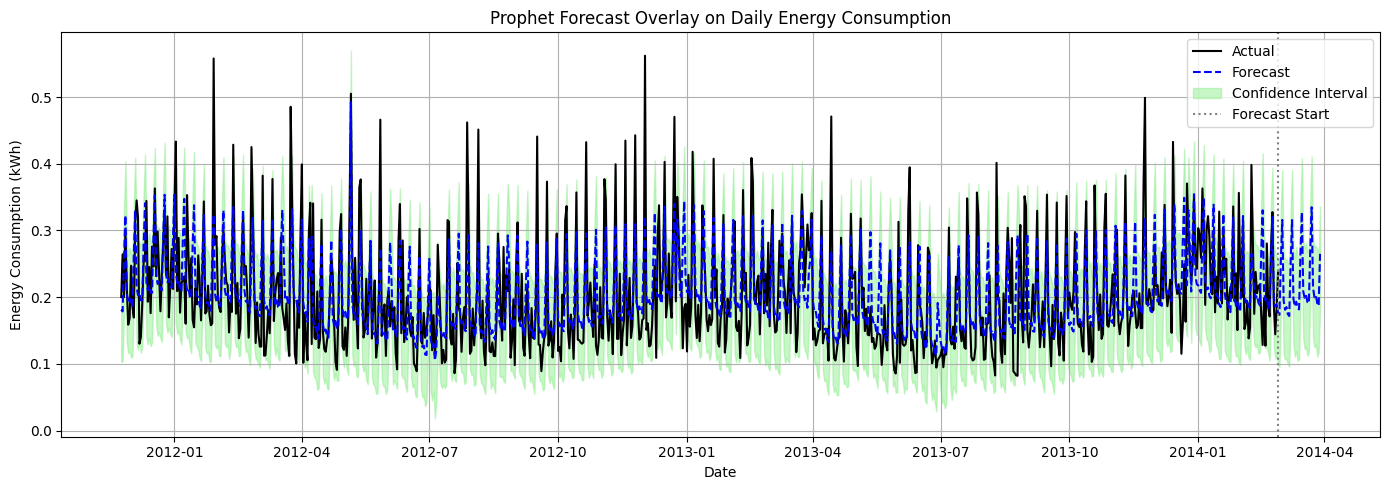

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Actual', color='black')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='blue', linestyle='--')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                 color='lightgreen', alpha=0.5, label='Confidence Interval')
plt.axvline(df_prophet['ds'].iloc[-1], color='gray', linestyle=':', label='Forecast Start')
plt.title('Prophet Forecast Overlay on Daily Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Prophet Forecast Overlay

This plot shows the actual energy consumption and the forecasted values from Prophet (30 days ahead), including:

- **Predicted trend (yhat)**
- **Confidence interval**
- **Forecast starting point**

The forecast accounts for both holidays and temperature effects.


In [17]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    model,
    initial='180 days',   
    period='30 days',     
    horizon='30 days'     
)
df_p = performance_metrics(df_cv)
df_p[['horizon', 'mae', 'rmse', 'mape']].head()


Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/21 [00:00<?, ?it/s]11:41:23 - cmdstanpy - INFO - Chain [1] start processing
11:41:23 - cmdstanpy - INFO - Chain [1] done processing
11:41:24 - cmdstanpy - INFO - Chain [1] start processing
11:41:24 - cmdstanpy - INFO - Chain [1] done processing
 10%|▉         | 2/21 [00:00<00:01, 14.92it/s]11:41:24 - cmdstanpy - INFO - Chain [1] start processing
11:41:24 - cmdstanpy - INFO - Chain [1] done processing
11:41:24 - cmdstanpy - INFO - Chain [1] start processing
11:41:24 - cmdstanpy - INFO - Chain [1] done processing
 19%|█▉        | 4/21 [00:00<00:01, 15.40it/s]11:41:24 - cmdstanpy - INFO - Chain [1] start processing
11:41:24 - cmdstanpy - INFO - Chain [1] done processing
11:41:24 - cmdstanpy - INFO - Chain [1] start processing
11:41:24 - cmdstanpy - INFO - Chain [1] done processing
 29%|██▊       | 6/21 [00:00<00:01, 13.89it/s]11:41:24 - cmdstanpy - INFO - Chain [1] st

,horizon,mae,rmse,mape
0,3 days,0.056557,0.071119,0.313490
1,4 days,0.058663,0.073595,0.315052
2,5 days,0.059057,0.073758,0.333645
3,6 days,0.058070,0.073952,0.337508
4,7 days,0.053396,0.069711,0.312407


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


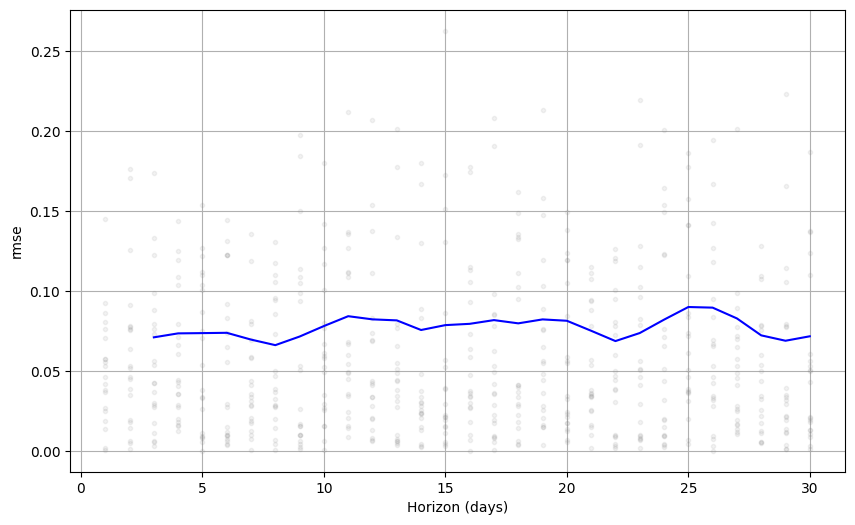

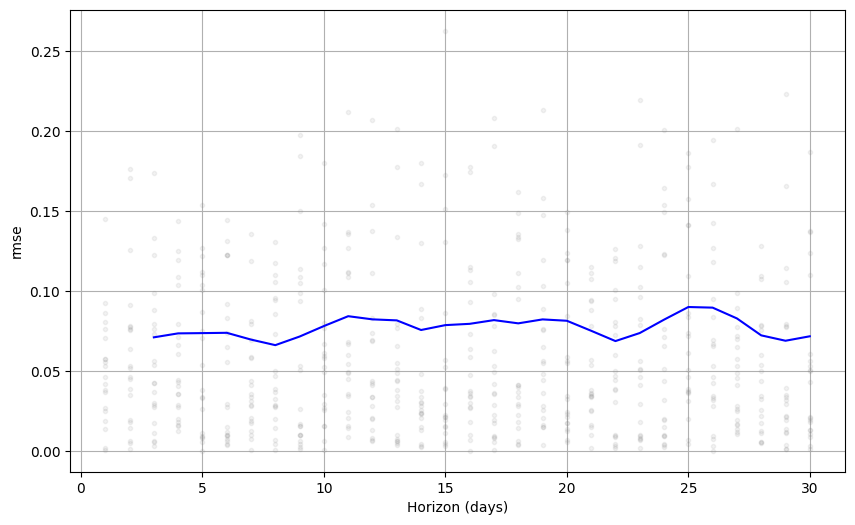

In [18]:
from prophet.plot import plot_cross_validation_metric

plot_cross_validation_metric(df_cv, metric='rmse')


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


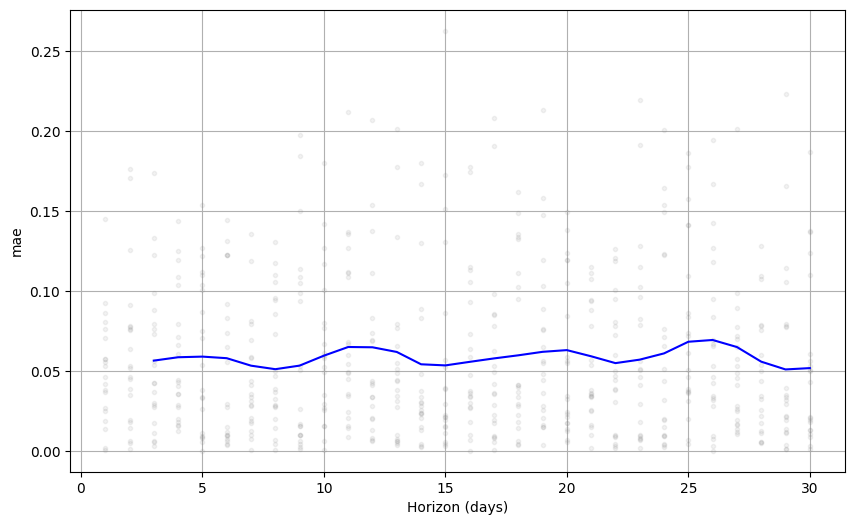

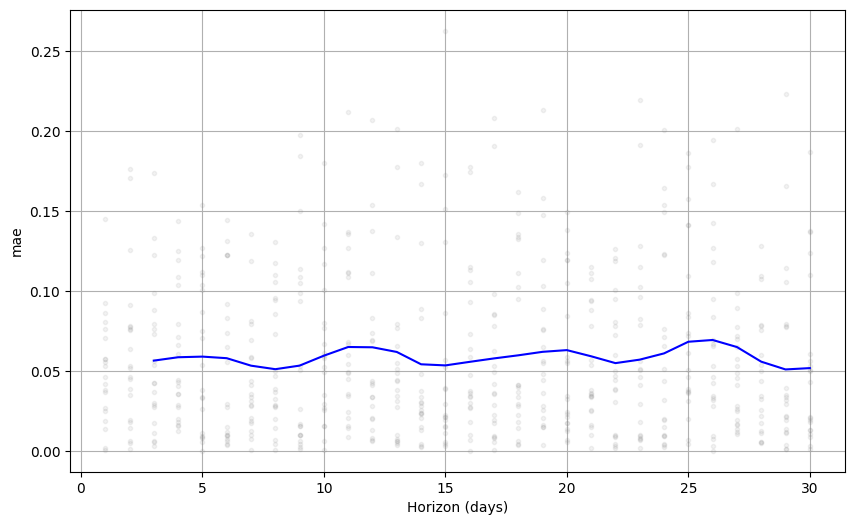

In [19]:
plot_cross_validation_metric(df_cv, metric='mae')

/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


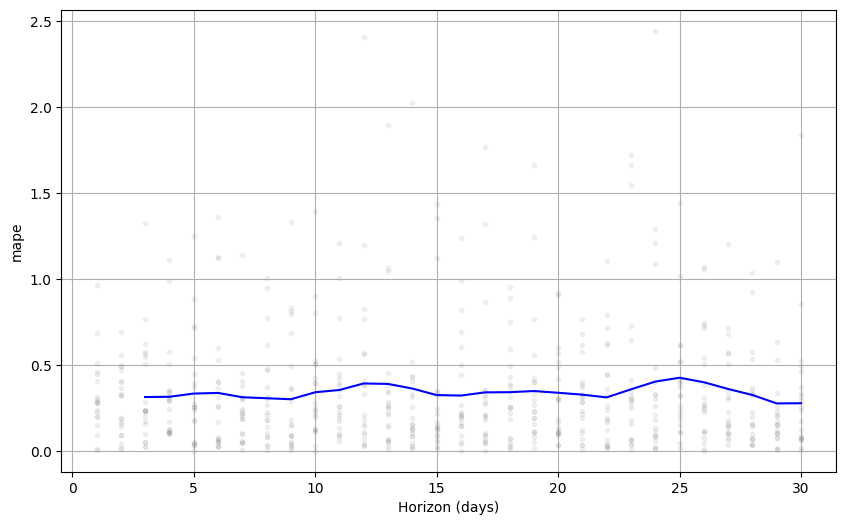

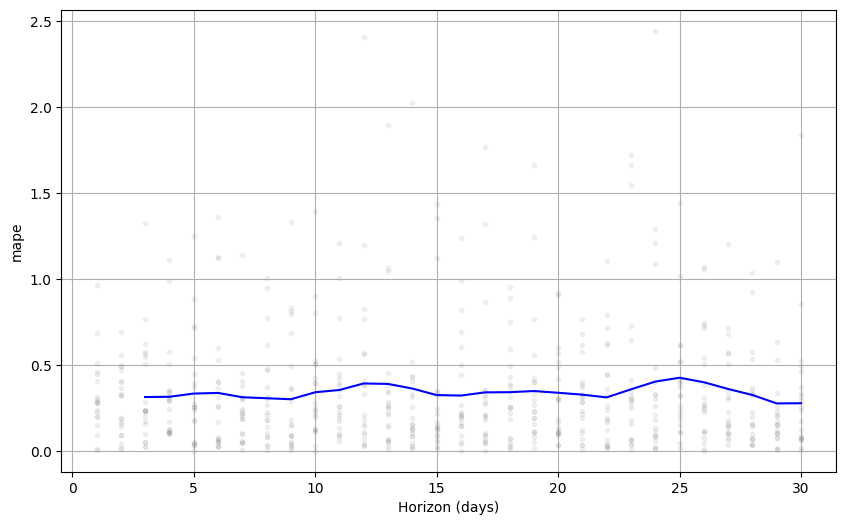

In [20]:
plot_cross_validation_metric(df_cv, metric='mape')

## Model Evaluation: Cross-Validation

We applied time-based cross-validation using Prophet’s `cross_validation()` to simulate rolling forecasts. Performance was evaluated over a 30-day forecast horizon, repeated every 30 days after a 180-day training window.

### Key Metrics:

- **MAE**: Mean Absolute Error
- **RMSE**: Root Mean Squared Error
- **MAPE**: Mean Absolute Percentage Error

This evaluation provides a robust estimate of how the model generalizes over time.


## Prophet Cross-Validation Summary

We evaluated the Prophet model using rolling cross-validation with a 30-day forecast horizon.

### Key Insights:

- **RMSE** and **MAE** remained stable across the forecast window, indicating consistent accuracy over time.
- **MAPE** was low and flat, showing reliable performance in percentage terms.
- There was no major increase in error as the horizon extended, suggesting the model generalizes well and doesn't overfit.

The model performs well for medium-range forecasting (up to 30 days), with good stability and low prediction error.
